# Zenodo Data Exploration Multimodal Drone Detection
By Ethan Mauger

This notebook documents fully exploring the Zenodo datasets researched to be applied to the Drone Detection Capstone project. The Zenodo Drone Detection datasets are 3 datasets featuring both thermal and visual images, as well as a set of augmented thermal images. They are linked in the offline_ml README.md.

## Basic Statistics

The code below shows us the total number of images per dataset, and the split between training, testing, and validation. We can see that the non-augmented sets are very similar in size, and the augmented set is larger due to the augmentations that created 5 total versions of each source image (test and valid images aren't augmented). Only one image appears to be missing from the non-augmented thermal dataset, assuming the same or very similar images were used for each set.

All of the data represents positive cases where a drone is identified, and the model must be trained to discover the bounding box of the drone in question. However, some of the **labels are missing in the thermal data**, and thus might need to be manually labeled or cross referenced with the visual data to find appropriate labels.

*Future Work: Determine negative cases, handle missing thermal data labels cases, change train/test/valid splits if necessary.*

In [ ]:
import os

dataset_names = [
    "zenodo_visual_no_augmentation",
    "zenodo_thermal_no_augmentation",
    "zenodo_thermal_augmented",
]
test_sets = ["train", "test", "valid"]

for dataset in dataset_names:
    print(f"Dataset: {dataset}")
    total = 0

    for subset in test_sets:
        base_dir = os.path.join("..", "datasets", dataset, subset)
        images_dir = os.path.join(base_dir, "images")
        print(f"{subset}: {len(os.listdir(images_dir))} images.")
        total += len(os.listdir(images_dir))

    print(f"Total Images: {total}")
    print("--------------------------")

Dataset: zenodo_visual_no_augmentation
train: 1502 images.
test: 214 images.
valid: 429 images.
Total Images: 2145
--------------------------
Dataset: zenodo_thermal_no_augmentation
train: 1504 images.
test: 211 images.
valid: 429 images.
Total Images: 2144
--------------------------
Dataset: zenodo_thermal_augmented
train: 7520 images.
test: 211 images.
valid: 429 images.
Total Images: 8160
--------------------------


In [ ]:
for dataset in dataset_names:
    print(f"Dataset: {dataset}")
    total = 0
    total_empty = 0

    for subset in test_sets:
        base_dir = os.path.join("..", "datasets", dataset, subset)
        labels_dir = os.path.join(base_dir, "labels")
        label_files = os.listdir(labels_dir)

        # Check to see which labels are empty.
        subset_empty = 0

        for label_file in label_files:
            file_path = os.path.join(labels_dir, label_file)

            with open(file_path) as f:
                content = f.read().strip()

            if not content:
                subset_empty += 1

        print(f"{subset}: {len(os.listdir(labels_dir))} labels.")
        print(f"{subset}: {subset_empty} empty labels.")
        print("------------------------")

        total_empty += subset_empty
        total += len(os.listdir(labels_dir))

    print(f"Total Labels: {total}")
    print(f"Total Empty Labels: {total_empty}")
    print("------------------------")
    print("------------------------")

Dataset: zenodo_visual_no_augmentation
train: 1502 labels.
train: 0 empty labels.
------------------------
test: 214 labels.
test: 0 empty labels.
------------------------
valid: 429 labels.
valid: 0 empty labels.
------------------------
Total Labels: 2145
Total Empty Labels: 0
------------------------
------------------------
Dataset: zenodo_thermal_no_augmentation
train: 1504 labels.
train: 268 empty labels.
------------------------
test: 211 labels.
test: 39 empty labels.
------------------------
valid: 429 labels.
valid: 77 empty labels.
------------------------
Total Labels: 2144
Total Empty Labels: 384
------------------------
------------------------
Dataset: zenodo_thermal_augmented
train: 7520 labels.
train: 546 empty labels.
------------------------
test: 211 labels.
test: 16 empty labels.
------------------------
valid: 429 labels.
valid: 27 empty labels.
------------------------
Total Labels: 8160
Total Empty Labels: 589
------------------------
------------------------


## Image Analysis

All images are in the .jpg format and each dataset's images have the same image size **(640 x 640 for visual and thermal_augmented, 640 x 512 for thermal_no_augmentation)**. To my understanding, the 640 x 512 image size is the original image size. The visual images have an RGB color scheme, whereas the thermal appears to be on a grayscale. 

All pictures are clear and in the daytime, but have varying weather varieties such as clear skies, cloudy, and overcast. The images depict varying backgrounds of the sky and other buildings/structures common around a suburban/school/farm area. There is also plenty of foiliage in the images as well, and the images are shared between the different datasets. These images provide a large range of different backgrounds and photos to allow training to occur, and will be super helpful in training a model to discover drones in similar areas.

For thermal specific images, the **thermal constrast seems somewhat difficult to interpret**. The grayscale seems to be accurate, but I could see thermal being a difficult challenge for the model to adapt to based on other similarly colored structures within the thermal images. This might lead to needing contrast augmentation on the images for the model to better understand.

It is **unknown if the thermal and visual images are exactly the same**/were taken at the same time, but further investigation will be done to determine if they can and should be paired up.

The thermal_augmented set also has specific augmentations completed on it. The augmentations documented by the dataset authors are below:
* 50% probability of horizontal flip
* 50% probability of vertical flip
* Equal probability of one of the following 90-degree rotations: none, clockwise, counter-clockwise
* Randomly crop between 0 and 25 percent of the image
* Random rotation of between -15 and +15 degrees
* Random brigthness adjustment of between -20 and +20 percent
* Random exposure adjustment of between -10 and +10 percent
* Random Gaussian blur of between 0 and 2.5 pixels
* Salt and pepper noise was applied to 1.52 percent of pixels

These augmentations seem useful, but more research will have to be done to determine what augmentations will be beneficial for our specific model. Augmentation will most likely be used later in the process to fine tune the model.

Looking at the bounding boxes below, it is clear that the labels are snug on the drones and all follow a consistent format. The boxes roughly match the drone's orientation, but it is also clear with the thermal datasets that missing labels don't indicate no drone or hard to see drone, but in fact should be included and aren't.

*Future Work: Resize images for consistency, create additional augmentations for all sets to improve model accuracy, augment thermal data if model performs poorly, pair up thermal and visual images.*

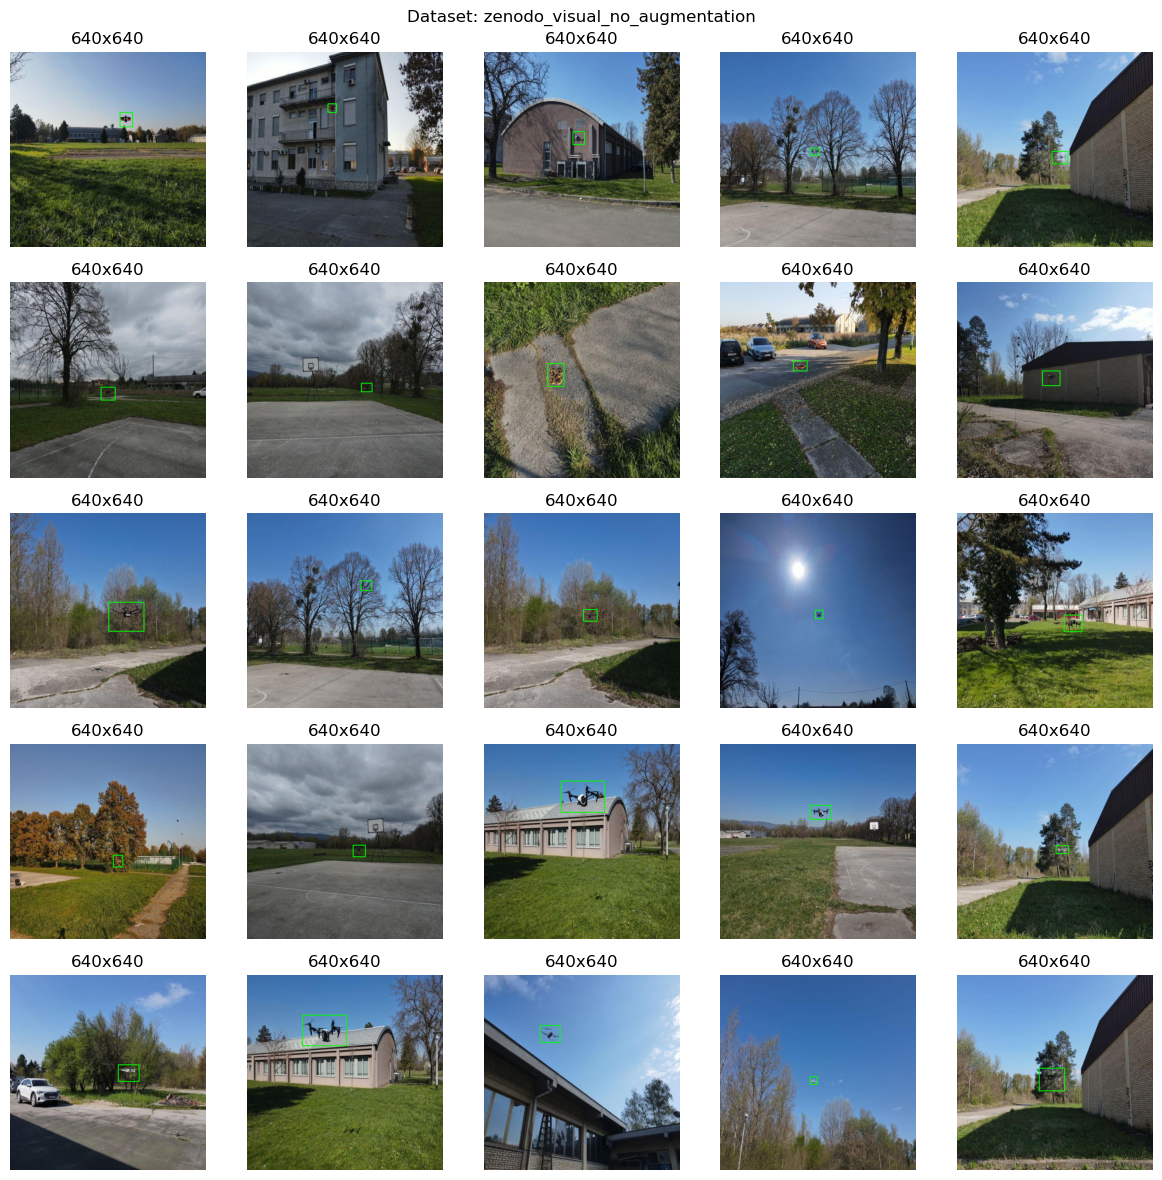

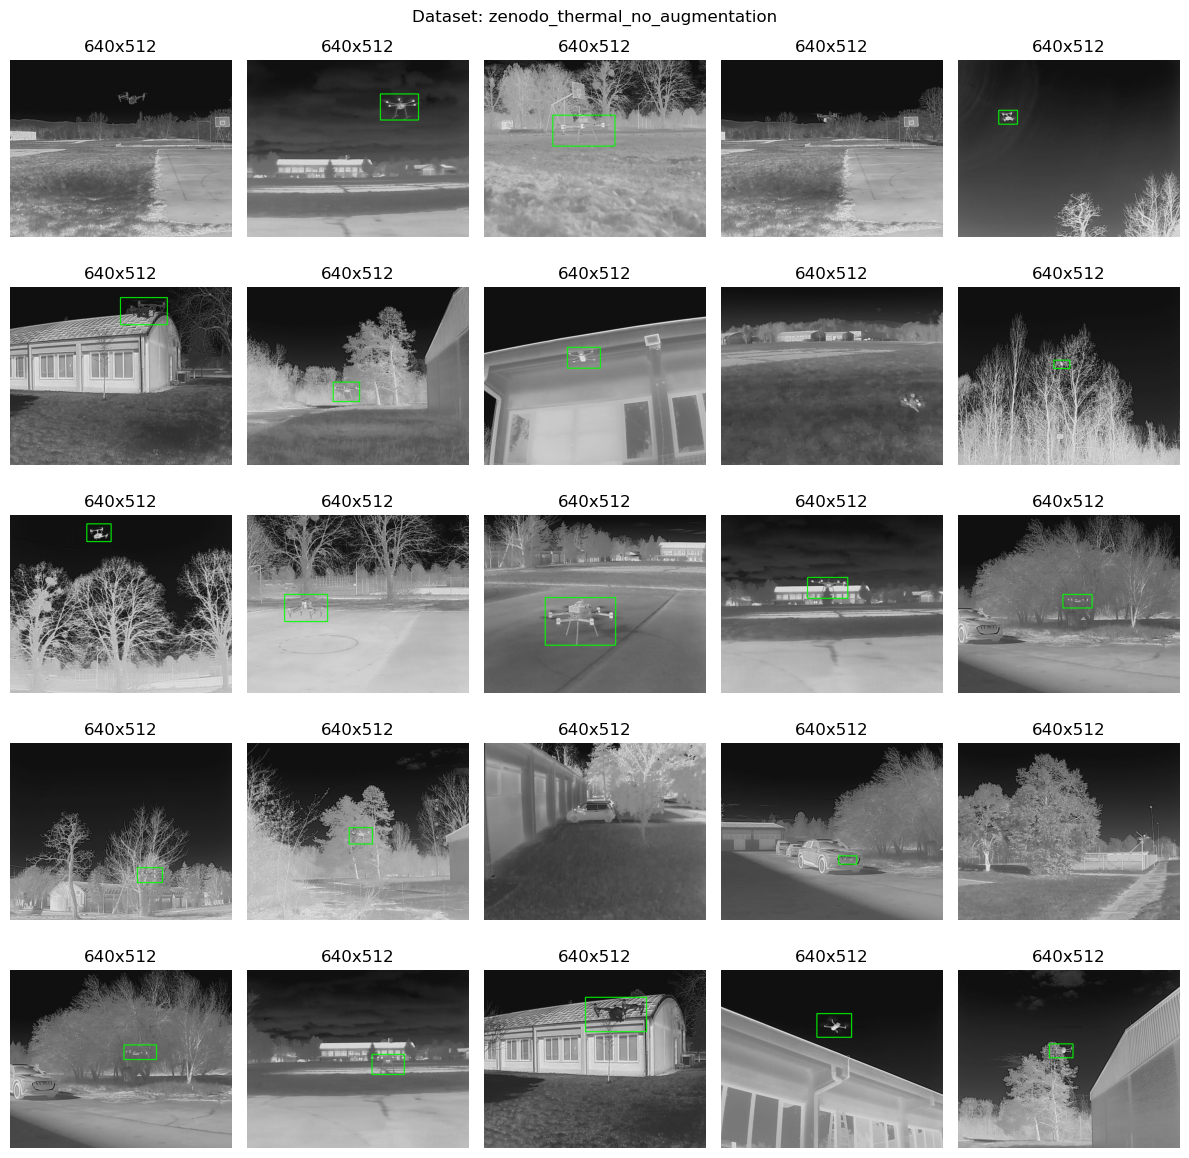

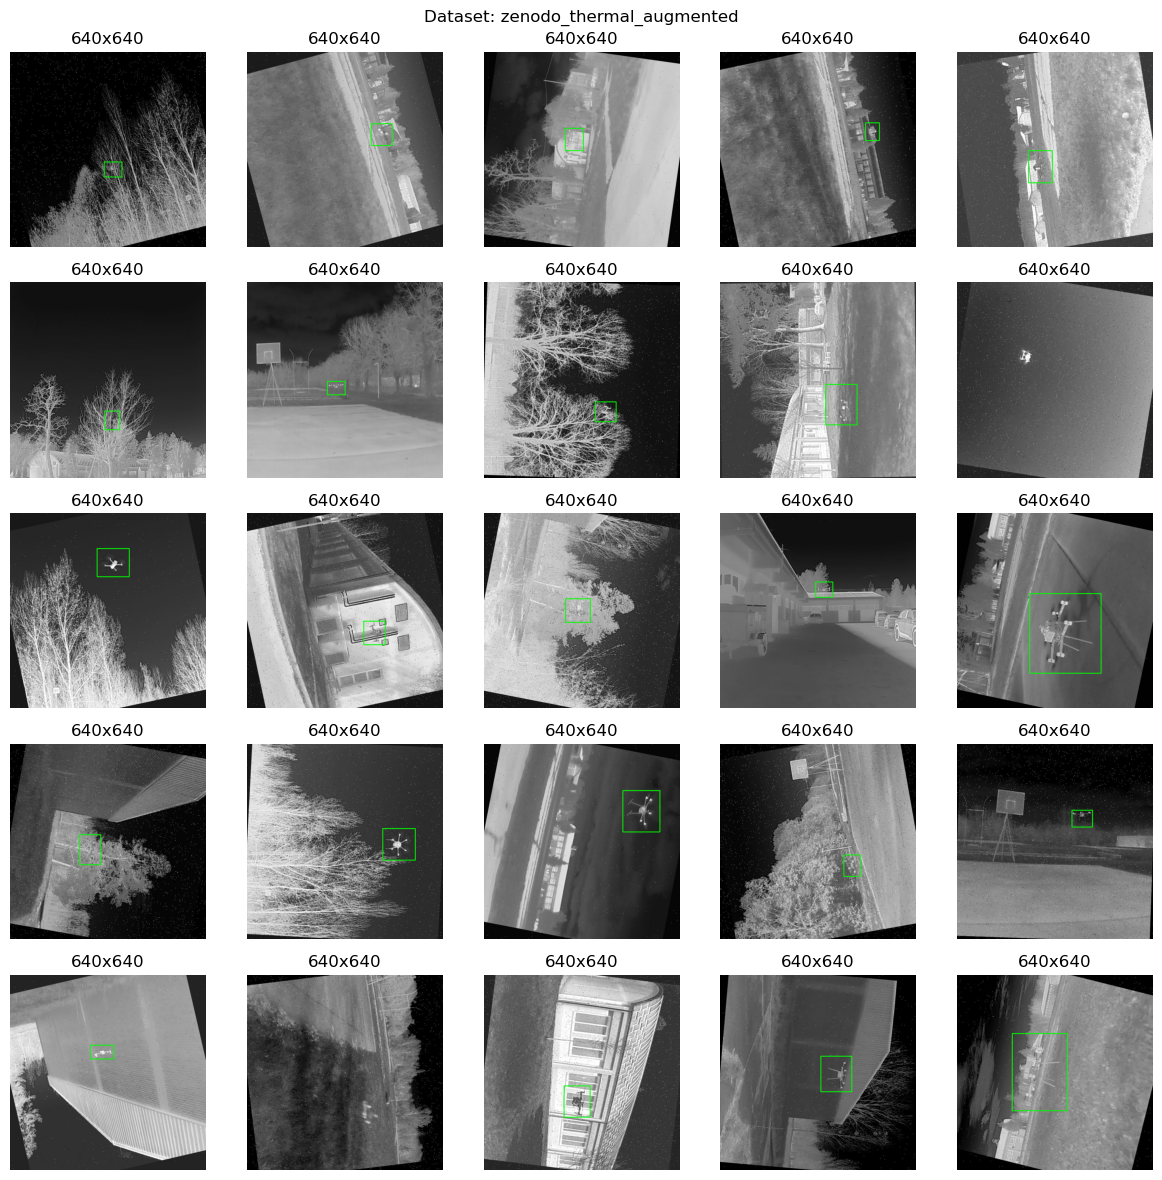

In [ ]:
import random

import cv2
import matplotlib.pyplot as plt
import numpy

# Images to show per dataset.
# Input should be a perfect square and should be less than the number of images in the dataset.
images_per_dataset = 25
grid_size = int(numpy.sqrt(images_per_dataset))

for dataset in dataset_names:
    base_dir = os.path.join("..", "datasets", dataset, "train", "images")
    labels_dir = os.path.join("..", "datasets", dataset, "train", "labels")
    image_files = os.listdir(base_dir)

    # Randomly select images.
    selected_images = random.sample(image_files, images_per_dataset)

    # Create plot structure.
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))
    axes = axes.flatten()
    fig.suptitle(f"Dataset: {dataset}")

    # Load images.
    for i, image_file in enumerate(selected_images):
        img_path = os.path.join(base_dir, image_file)
        img = cv2.imread(img_path)

        # Load labels for bounding boxes for each image.
        label_path = os.path.join(labels_dir, image_file.replace(".jpg", ".txt"))

        with open(label_path) as f:
            content = f.read().split()

            # If the file is labeled, produce a bounding box given the normalized center
            # of the box and the box width and height.
            if content:
                x = float(content[1])
                y = float(content[2])
                w = float(content[3])
                h = float(content[4])

                # Convert to pixel coordinates and display to the screen.
                x1 = int((x - w / 2) * img.shape[1])
                y1 = int((y - h / 2) * img.shape[0])
                x2 = int((x + w / 2) * img.shape[1])
                y2 = int((y + h / 2) * img.shape[0])
                cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Display image and size of image.
        axes[i].imshow(img_rgb)
        axes[i].axis("off")
        axes[i].set_title(f"{img.shape[1]}x{img.shape[0]}")

    plt.tight_layout()
    plt.show()

## Bounding Box Analysis

The following section checks the dirstribution of location and sizes of the different bounding boxes for each of the three datasets based on the labels provided. Looking at the location of the bounding boxes, we can see that the visual data has the boxes firmly in the center, and features fairly small bounding boxes with a few larger one scattered in the data. The data features a couple of drones of varying sizes and makeups, but based on the positioning of the camera the bounding boxes will change. Because of the **similarities of the bounding box sizes and locations**, augmentation could be useful, however, smaller bounding boxes could be useful for drone detection from futher distances.

The thermal data is similar, which makes sense due to the similarity in images. One thing to note is that due to the differing sizes of the images between the visual and the thermal data, the bounding boxes are shifted a little lower than usual. Also, there are less dots in the thermal data because images without labels were omitted. However, the augmentation seemed to really help, preserving the size of the bounding boxes but drastically increasing the location of the bounding box. This could be extremely useful for training model edge cases when only the drone is slightly in frame.

*Future Work: Determine if bigger bounding boxes will be useful, expand location of bounding boxes as model improves with image augmentation*

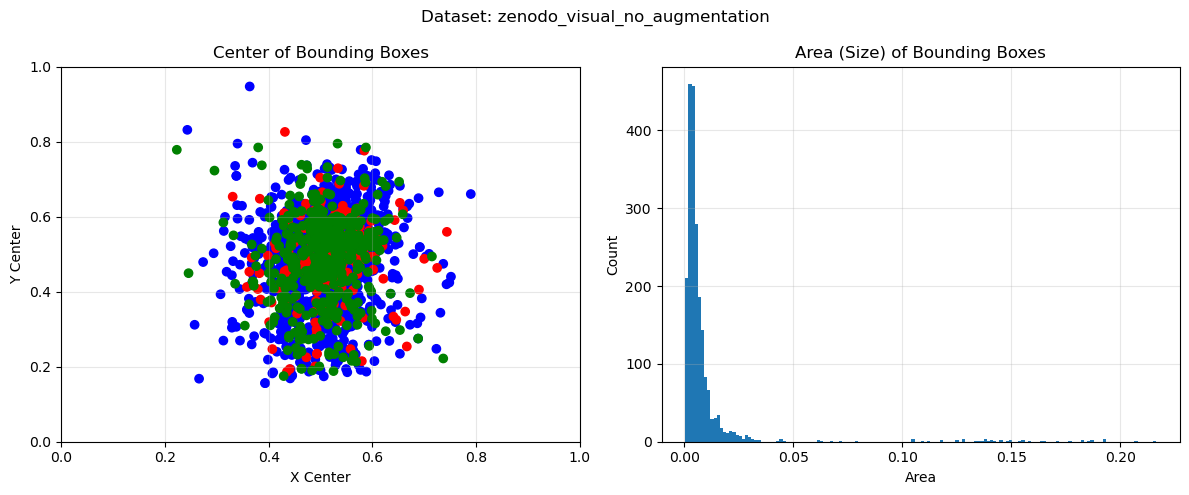

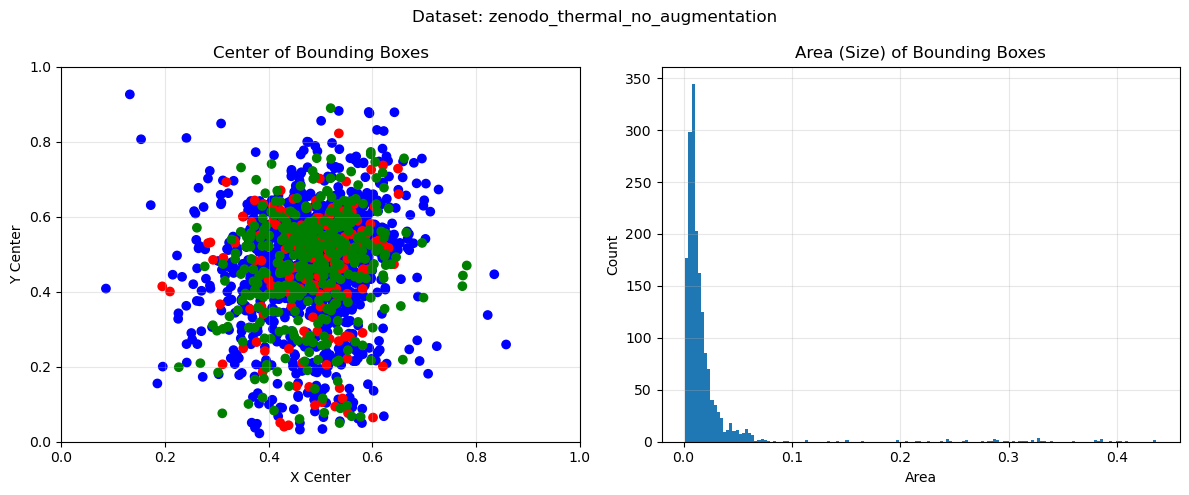

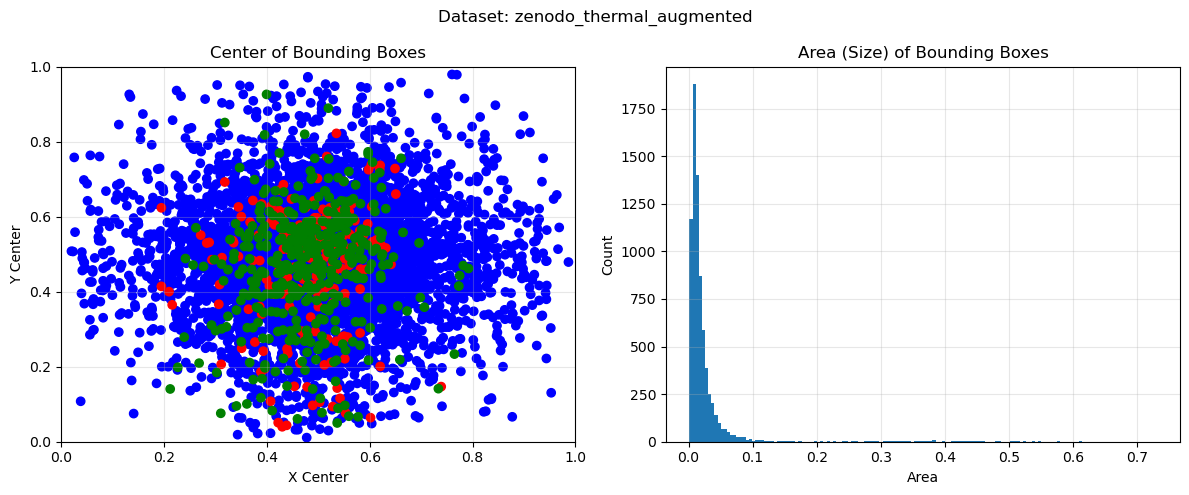

In [ ]:
for dataset in dataset_names:
    # Store data from labels.
    all_x = []
    all_y = []
    all_areas = []
    subset_colors = []

    # Map colors to test set.
    colors = {"train": "blue", "valid": "green", "test": "red"}

    for subset in test_sets:
        base_dir = os.path.join("..", "datasets", dataset, subset)
        labels_dir = os.path.join(base_dir, "labels")
        label_files = os.listdir(labels_dir)

        for label_file in label_files:
            label_path = os.path.join(labels_dir, label_file)

            # Get numbers in labels.
            with open(label_path) as f:
                content = f.read().split()

                # Set numbers to be displayed in graphs based on what they represent
                # (location/size of bounding box).
                if content:
                    x = float(content[1])
                    y = float(content[2])
                    w = float(content[3])
                    h = float(content[4])

                    # Add values to the list.
                    all_x.append(x)
                    all_y.append(y)
                    all_areas.append(w * h)
                    subset_colors.append(colors[subset])

    # Create plots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(f"Dataset: {dataset}")

    # Scatter plot for the center of bounding boxes
    ax1.scatter(all_x, all_y, c=subset_colors)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
    ax1.set_xlabel("X Center")
    ax1.set_ylabel("Y Center")
    ax1.set_title("Center of Bounding Boxes")
    ax1.grid(True, alpha=0.3)

    # Histogram of areas
    ax2.hist(all_areas, bins=150)
    ax2.set_xlabel("Area")
    ax2.set_ylabel("Count")
    ax2.set_title("Area (Size) of Bounding Boxes")
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

## Conclusion

Based on the preceding exploration of the Zenodo visual and thermal datasets, here are some strengths and weaknesses of the dataset and what future work could look like:

Strengths:
* Clean, high-quality images
* Variety of scenes
* test sets are comprehensive
* Difficult cases of spotting drones is included
* Labeled drones are accuratly labeled and no false positives are labeled incorrectly.

Weaknesses:
* Missing thermal labels on about 18% of images
* Thermal contrast might be too difficult to spot drones
* Visual and thermal images have different dimensions
* Bounding boxes have somewhat low distribution between size and location
* Don't know if the thermal and visual datasets are the same images

Future Work/Preprocessing:
* Normalize dimensions between images
* Determine fix for missing thermal labels
* Apply augmentation for contrast and bounding box diversity